In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

In [4]:
import sys
sys.path.append('..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinFoldingResult
from vqe import VQEC, VQECOpt
from qiskit.circuit.library import RealAmplitudes
from qiskit.primitives import Sampler, Estimator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient, LinCombEstimatorGradient
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    # penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem

In [6]:
main_seq_4 = "LFLF" # 6MVZ ("LFLF")
protein_folding_problem = build_pf(main_seq_4)
qubit_op = protein_folding_problem.qubit_op()
print(f"Number of qubits: {qubit_op.num_qubits}")
print(f"Number of terms: {len(qubit_op)}")

[[ 0.   -7.28 -7.37 -7.28]
 [ 0.    0.   -7.28 -7.26]
 [ 0.    0.    0.   -7.28]
 [ 0.    0.    0.    0.  ]]
Number of qubits: 9
Number of terms: 107


In [7]:
bead_pairs, olap_constr_ops = protein_folding_problem.olap_constr_ops()
print(f"Number of overlap constraints: {len(olap_constr_ops)}")
print(f"Number of qubits: {olap_constr_ops[0].num_qubits}")

Number of overlap constraints: 1
Number of qubits: 9


In [24]:
ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1)
estimator = Estimator()
gradient = LinCombEstimatorGradient(estimator=estimator)
vqec = VQECOpt(qubit_op=qubit_op, constr_ops=olap_constr_ops, ansatz=ansatz, estimator=estimator, gradient=gradient)
vqec_result = vqec.optimize_primal_dual()
print(vqec_result.optimal_primal_vars)
print(vqec_result.optimal_dual_vars)

[ 4.03569253e-04 -6.10893526e-06  3.59820358e+00  3.13180833e+00
 -1.41242255e-02  6.08838141e-02  3.14122763e+00  3.14283883e+00
  2.86865829e+00  6.26037755e+00  3.14156208e+00  5.54972209e-01
  6.48036726e+00  1.13750713e-01  2.89789100e+00  6.26466579e+00
  2.67912715e-03 -2.69486775e-01]
[0.]


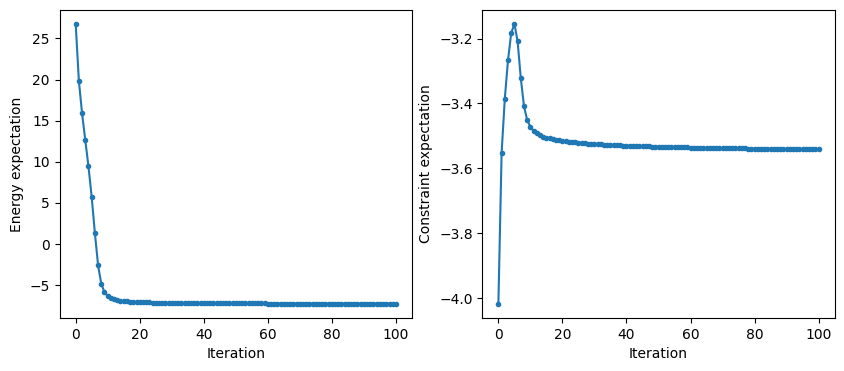

In [35]:
# Plot the results
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(vqec_result.energies, label="Energy", marker=".")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Energy expectation")

ax[1].plot(vqec_result.constraints[:, 0], label="Overlap", marker=".")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Constraint expectation")

plt.show()

In [38]:
full_circ = vqec_result.ansatz.copy()
full_circ.measure_all()
sampler = Sampler(options={"shots": 10000})
sampler_result = sampler.run(circuits=[full_circ], parameter_values=vqec_result.optimal_primal_vars).result()
quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()

# Sort the binary strings by their probabilities
sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))
# Compute the energies of all samples
from qufold.execution_utils.measurements import _evaluate_sparsepauli
bitstring_energies = {}
for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
    if i >= 5:
        break
    energy = _evaluate_sparsepauli(sample, qubit_op)
    bitstring_energies[sample] = energy
    print(f"Sample {i}: {sample} with probability {prob} and energy {energy}")

Sample 0: 001110110 with probability 0.8646 and energy -7.369999999999994
Sample 1: 001111010 with probability 0.0575 and energy -7.369999999999996
Sample 2: 001110010 with probability 0.0571 and energy -7.369999999999994
Sample 3: 001010110 with probability 0.0127 and energy -7.369999999999999
Sample 4: 001100110 with probability 0.0034 and energy -7.370000000000006


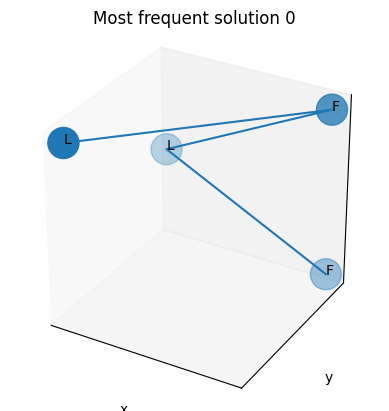

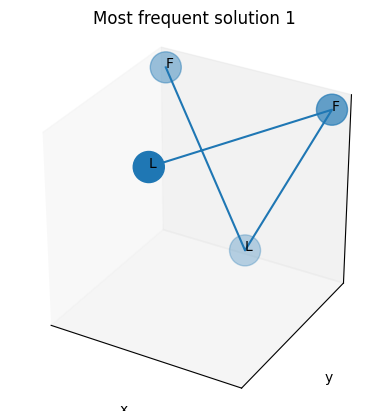

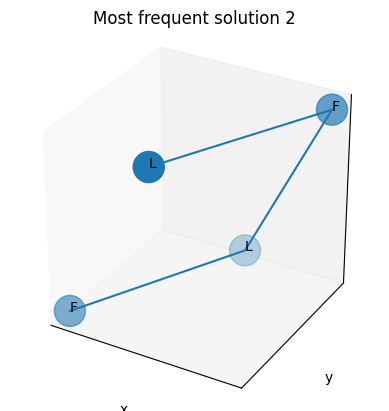

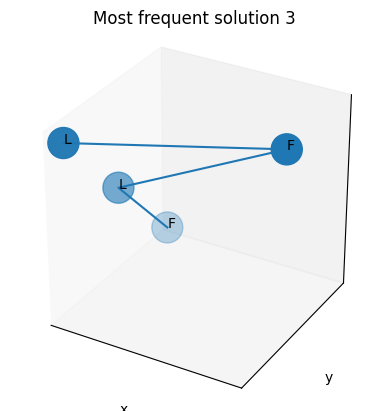

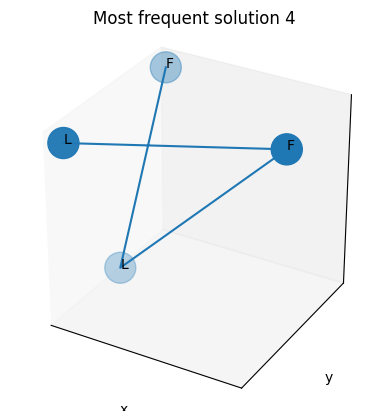

In [39]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    fig = pf_result.get_figure(title=f"Most frequent solution {i}")
    plt.show()